Multivariate Regression Equation (using Normal Equation):
Coefficients: [[2. 2.]]
Intercept: [-3.55271368e-15  1.00000000e+00]

Predicted y1 values: [2. 4. 6.]
Predicted y2 values: [3. 5. 7.]

Regression Line Equations:
y1_pred = -0.00 + 2.00 * x
y2_pred = 1.00 + 2.00 * x

Error Metrics:

Metrics for y1:
  Mean Absolute Error (MAE): 0.00
  Mean Squared Error (MSE): 0.00
  R-squared (R2): 1.00
  Adjusted R-squared (Adj. R2): 1.00
  Root Mean Squared Error (RMSE): 0.00

Metrics for y2:
  Mean Absolute Error (MAE): 0.00
  Mean Squared Error (MSE): 0.00
  R-squared (R2): 1.00
  Adjusted R-squared (Adj. R2): 1.00
  Root Mean Squared Error (RMSE): 0.00


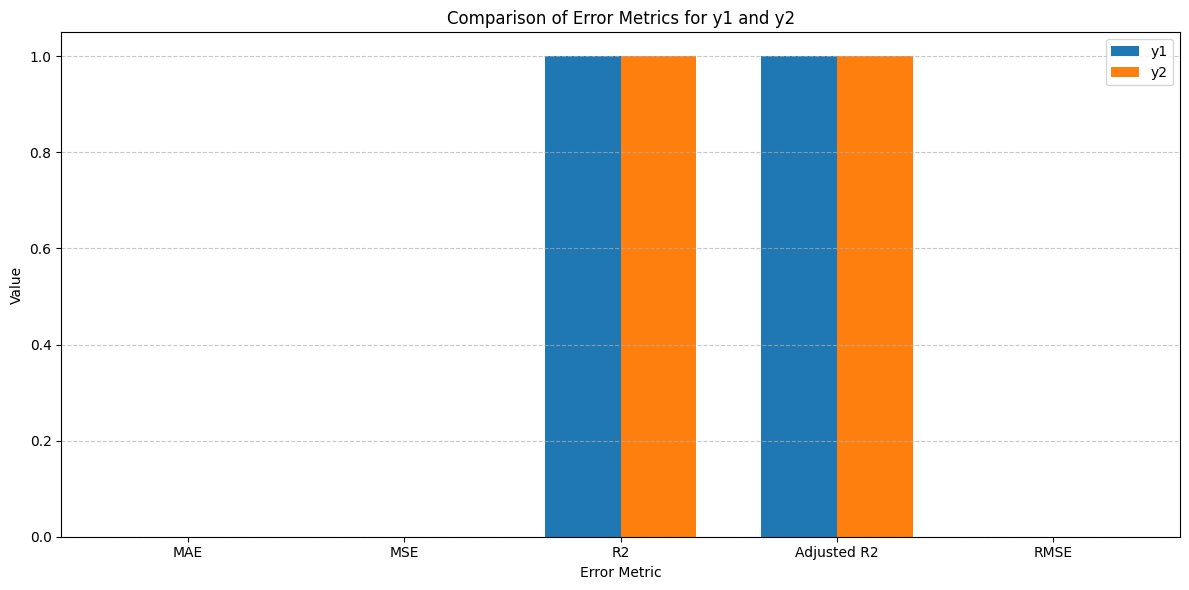

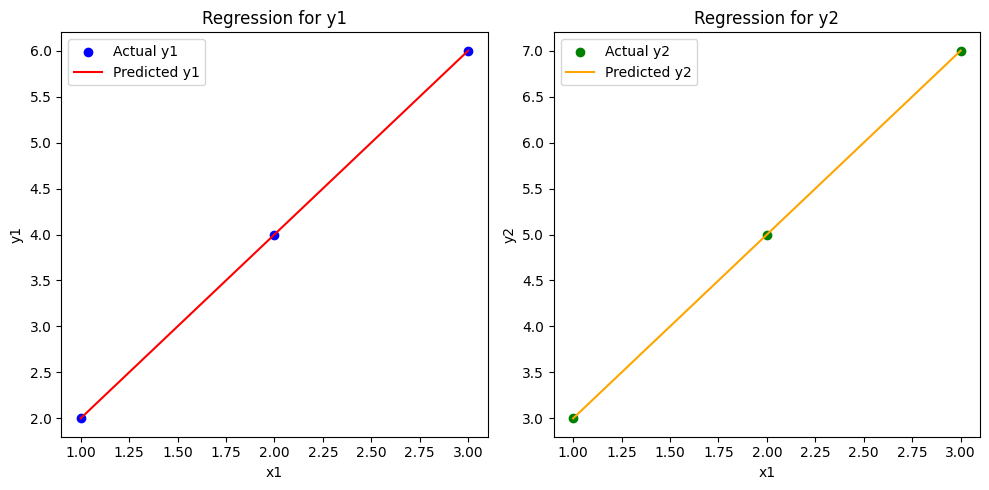

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x1 = np.array([1, 2, 3])
y1 = np.array([2, 4, 6])
y2 = np.array([3, 5, 7])

# Reshape x1 for sklearn (it expects a 2D array: n_samples, n_features)
X = x1.reshape(-1, 1)

# Combine y1 and y2 into a single target array for multivariate regression
Y = np.column_stack((y1, y2))

# Implement the Normal Equation
# Add a bias (intercept) term to X
X_b = np.c_[np.ones((X.shape[0], 1)), X] # Add column of ones

# Calculate theta using the Normal Equation: theta = (X_b.T @ X_b)^-1 @ X_b.T @ Y
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

# Extract intercept and coefficients
intercept = theta[0]
coefficients = theta[1:]

# Make predictions using the calculated theta
Y_pred = X_b @ theta

# Print the regression equation coefficients and intercept
print("Multivariate Regression Equation (using Normal Equation):")
print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")

# Print the predicted values
print(f"\nPredicted y1 values: {Y_pred[:, 0]}")
print(f"Predicted y2 values: {Y_pred[:, 1]}")

# Print the regression line equations
print("\nRegression Line Equations:")
print(f"y1_pred = {intercept[0]:.2f} + {coefficients[0,0]:.2f} * x")
print(f"y2_pred = {intercept[1]:.2f} + {coefficients[0,1]:.2f} * x")

# Perform error metrics for each output variable
print("\nError Metrics:")
metrics_data = {'Metric': ['MAE', 'MSE', 'R2', 'Adjusted R2', 'RMSE']}

n = X.shape[0]  # Number of observations
p = X.shape[1]  # Number of predictors (features excluding intercept)

for i, col_name in enumerate(['y1', 'y2']):
    print(f"\nMetrics for {col_name}:")
    mae = mean_absolute_error(Y[:, i], Y_pred[:, i])
    mse = mean_squared_error(Y[:, i], Y_pred[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(Y[:, i], Y_pred[:, i])
    # Calculate Adjusted R2
    # Only calculate if n > p + 1 to avoid division by zero or negative denominator
    if (n - p - 1) > 0:
        adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    else:
        adjusted_r2 = np.nan # Not meaningful to calculate

    print(f"  Mean Absolute Error (MAE): {mae:.2f}")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")
    print(f"  Adjusted R-squared (Adj. R2): {adjusted_r2:.2f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.2f}")
    metrics_data[col_name] = [mae, mse, r2, adjusted_r2, rmse]

# Plotting the error metrics as bar graphs
metrics_df = np.array([metrics_data['y1'], metrics_data['y2']])
metrics_names = metrics_data['Metric']

fig, ax = plt.subplots(figsize=(12, 6)) # Increased width for new metric

bar_width = 0.35
index = np.arange(len(metrics_names))

bar1 = ax.bar(index, metrics_df[0], bar_width, label='y1')
bar2 = ax.bar(index + bar_width, metrics_df[1], bar_width, label='y2')

ax.set_xlabel('Error Metric')
ax.set_ylabel('Value')
ax.set_title('Comparison of Error Metrics for y1 and y2')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optional: Plotting the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X, Y[:, 0], color='blue', label='Actual y1')
plt.plot(X, Y_pred[:, 0], color='red', label='Predicted y1')
plt.title('Regression for y1')
plt.xlabel('x1')
plt.ylabel('y1')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X, Y[:, 1], color='green', label='Actual y2')
plt.plot(X, Y_pred[:, 1], color='orange', label='Predicted y2')
plt.title('Regression for y2')
plt.xlabel('x1')
plt.ylabel('y2')
plt.legend()

plt.tight_layout()
plt.show()